# Joint SSMT — Trial-Structured Quickstart

This notebook walks through the **trial-structured (hierarchical)** spike-field coupling pipeline:

1. **Simulate** synthetic multi-trial LFP + spike data with known coupling
2. **Run hierarchical inference** using the Joint SSMT trial-structured model
3. **Interpret the core results** — coupling detection heatmaps and spectrogram
4. Additional diagnostic and comparison plots


In [16]:
# If you haven't installed the package yet, uncomment and run:
# !pip install -e ..


In [17]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

from joint_ssmt.io import run_inference_trials, load_results_trials


---
## 1. Simulate Trial-Structured Data

We use the trial simulator (in `manuscript_figures/trial_structure/`) to generate multi-trial data with shared OU latents plus trial-specific deviations.

> **For real data** you would skip this step and load your own `lfp` (2-D array, shape `(R, T)`) and `spikes` (3-D array, shape `(R, S, T_fine)`).


In [18]:
# Add the trial simulator to path
sys.path.insert(0, '../manuscript_figures/trial_structure')
from simulate_trial_data import TrialSimConfig, simulate_trials

cfg = TrialSimConfig(
    R=30,                   # 20 trials (use >=50 for real analyses)
    S=3,                    # 3 spike units
    k_active=2,             # each unit couples to 2 of 4 couplable bands
    duration_sec=5.0,       # 5 s per trial
    b0_mu=-3.0,             # baseline log-odds (controls mean firing rate)
)

sim = simulate_trials(cfg, seed=42)

lfp    = sim['LFP']        # (R, T)
spikes = sim['spikes']     # (R, S, T_fine)
fs     = cfg.fs

R, T = lfp.shape
_, S, T_fine = spikes.shape

print(f"LFP shape:    {lfp.shape}   (R={R} trials, T={T} samples at {fs} Hz)")
print(f"Spikes shape: {spikes.shape} (S={S} units)")
print(f"\nGround-truth coupled frequencies: {sim['freqs_hz_coupled']}")
print(f"Signal-only (uncoupled) frequencies: {sim['freqs_hz_extra']}")
print(f"\nCoupling mask (rows=units, cols=signal bands):")
print(sim['masks'])


Simulation setup:
  Trials: R=30, Units: S=3
  Coupled signal bands (Jc=4): [11. 19. 27. 43.]
  Extra uncoupled signal bands (Ju=2): [ 7. 35.]
  Total signal bands (J=6): [11. 19. 27. 43.  7. 35.]
  LFP: T=5000 samples at fs=1000.0 Hz
  Spikes: T_fine=5000 samples at 1000.0 Hz
  b0_mu=-3.0 (baseline firing rate parameter)
  Dense frequency grid: F=60 frequencies (1 to 60 Hz)
  Signal frequency indices in dense grid: [ 6 10 18 26 34 42]
Generating shared OU processes...
Generating trial-specific OU deltas...
Computing derotated latents for spike predictors...
Generating coupling parameters...
  beta_true shape: (3, 13)
  masks shape: (3, 6)
Generating spikes...
  Spikes per unit: [4332 5176 4141]
  Mean firing rate: 30.33 Hz
Generating LFP with broadband noise...
Simulation complete.
LFP shape:    (30, 5000)   (R=30 trials, T=5000 samples at 1000.0 Hz)
Spikes shape: (30, 3, 5000) (S=3 units)

Ground-truth coupled frequencies: [11. 19. 27. 43.]
Signal-only (uncoupled) frequencies: [ 7. 3

---
## 2. Run Inference

Call `run_inference_trials` with your trial-structured LFP, spike trains, and config dictionaries.

**Key parameters (different from single-trial):**
- `window_sec=0.4` — shorter window for short trials
- `freq_step=2.0` — coarser frequency grid
- `time_bandwidth=1.0` — fewer tapers for short windows
- `downsample_factor=10` — downsample saved fine state

> **Timing:** ~2–5 min for 30 trials × 5 s with these settings. For publication quality, increase `warmup_iterations` to 1000 and `n_refresh_cycles` to 5.


> **Sidebar.** For a one-call data-in / figures-out workflow on trial-structured data, use `joint_ssmt.run_auto_inference(lfp, spikes, fs, trial_structure=True)`. See `examples/auto_inference_demo.ipynb`. The rest of this quickstart uses the lower-level `run_inference_trials()` so the configs are visible.


In [19]:
saved = run_inference_trials(
    lfp=lfp,
    spikes=spikes,
    spectral_config={
        'freq_min': 1.0,
        'freq_max': 61.0,
        'freq_step': 2.0,       # coarser grid for short trials
        'window_sec': 0.4,      # shorter window for trial data
        'time_bandwidth': 1.0,  # NW=1 (fewer tapers for short windows)
    },
    inference_config={
        'warmup_iterations': 200,
        'n_refresh_cycles': 2,
        'iterations_per_refresh': 50,
    },
    output_config={
        'output_dir': './results_trials',
        'save_spectral': True,
        'downsample_factor': 10,
    },
    fs=fs,
    plot=False,
)

print("Saved files:")
for k, v in saved.items():
    print(f"  {k}: {v}")


[EM-CT-HIER-JAX] iter 0  Q=-4.783287e+04
[EM-CT-HIER-JAX] iter 1000  Q=-3.765001e+04


Warmup (trial PG-Gibbs): 100%|██████████| 200/200 [00:20<00:00,  9.57it/s]


[EM-CT-HIER-JAX] iter 0  Q=-4.783287e+04
Saved files:
  coupling: ./results_trials/coupling.npz
  spectral: ./results_trials/spectral.npz
  lfp_only: ./results_trials/ctssmt_lfp_only.npz
  metadata: ./results_trials/metadata.json


---
## 3. Core Results

The results are stored as `.npz` and `.json` files. Use `load_results_trials()` to read them into a single dictionary.


In [20]:
results = load_results_trials('./results_trials')

# The main results live under 'coupling'
coupling = results['coupling']
freqs    = coupling['freqs']       # (J,) frequency grid
beta_mag = coupling['beta_mag']    # (S, J) posterior mean |beta|

S, J = beta_mag.shape
print(f"Frequency grid: {J} bands from {freqs[0]:.0f} to {freqs[-1]:.0f} Hz")
print(f"Units: {S}, Trials: {results['metadata']['data']['n_trials']}")


Frequency grid: 30 bands from 1 to 59 Hz
Units: 3, Trials: 30


### 3a. Coupling Detection Heatmap

This is **the key figure**. The Wald test checks whether each complex coupling coefficient $\beta$ is significantly different from zero.

- **Left panel:** posterior mean coupling magnitude $|\mathbb{E}[\beta]|$ — larger values indicate stronger coupling
- **Right panel:** $-\log_{10}(p)$ from the Wald $\chi^2(2)$ test — values above the cyan line ($\alpha = 0.05$) are statistically significant


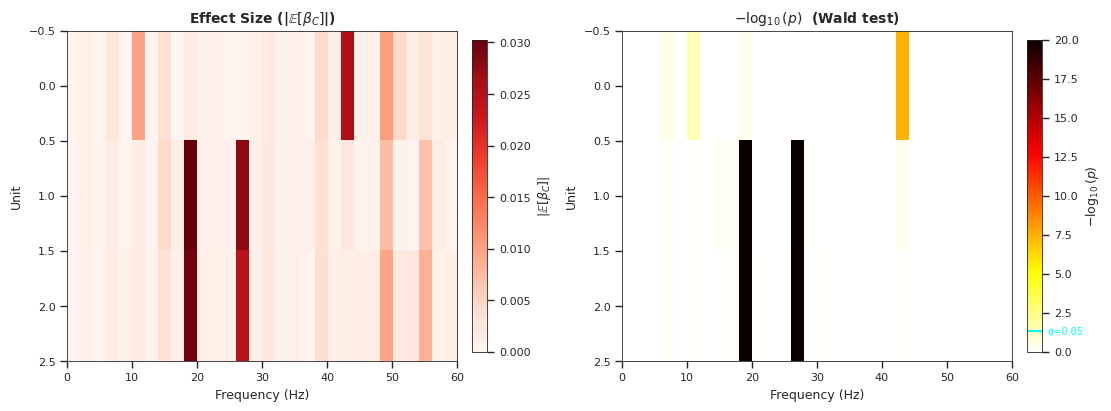

In [21]:
from joint_ssmt.plotting.summary import plot_coupling_summary

fig = plot_coupling_summary(results, effect_type='wald', alpha=0.05, figsize=(11, 4))
plt.show()


### 3b. Significant Coupling Pairs

Read off which (unit, frequency) pairs pass the Wald test.


In [22]:
wald_pval = coupling['wald_pval']   # (S, J)
wald_W    = coupling['wald_W']      # (S, J)
alpha = 0.05

print(f"Significant coupling pairs (alpha = {alpha}):\n")
print(f"  {'Unit':>4}  {'Freq (Hz)':>10}  {'|beta|':>8}  {'Wald W':>8}  {'p-value':>10}")
print("  " + "-" * 50)

for s in range(S):
    for j in range(J):
        if wald_pval[s, j] < alpha:
            print(f"  {s:>4}  {freqs[j]:>10.0f}  {beta_mag[s, j]:>8.4f}  "
                  f"{wald_W[s, j]:>8.2f}  {wald_pval[s, j]:>10.2e}")


Significant coupling pairs (alpha = 0.05):

  Unit   Freq (Hz)    |beta|    Wald W     p-value
  --------------------------------------------------
     0          11    0.0098      7.04    2.96e-02
     0          43    0.0257     34.01    4.13e-08
     1          19    0.0366    682.87    0.00e+00
     1          27    0.0278    178.11    0.00e+00
     2          19    0.0295    476.77    0.00e+00
     2          27    0.0245    118.89    0.00e+00


### 3c. Spectrogram

The inferred spectrogram shows how spectral power evolves over time. This works on **real data** too (no ground truth needed). The joint model refines the raw multitaper estimate by leveraging spike information.


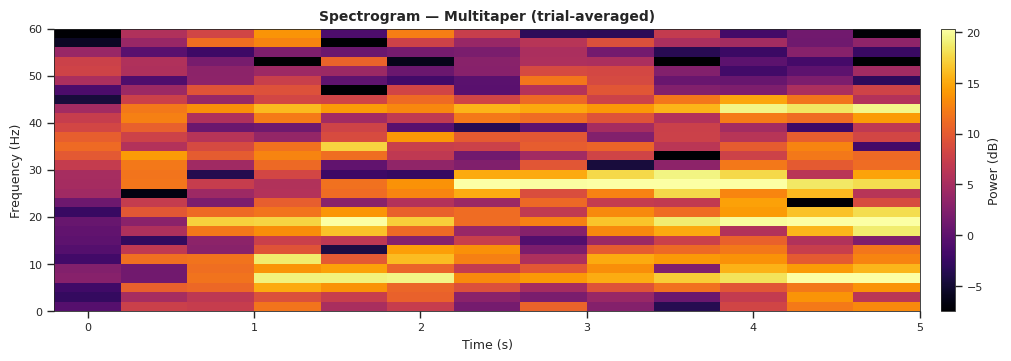

In [28]:
from joint_ssmt.plotting.summary import plot_spectrogram

# Joint model spectrogram (refined by spike information)
fig = plot_spectrogram(results, method='joint', figsize=(10, 3.5))
plt.show()



The Joint SSMT model also returns the posterior **variance** at each (frequency, time), so we can put 95% credible bands on the spectral amplitude. Frequencies where spike timing carries information about the LFP tend to have tighter credible bands.


### 3d. Metadata

The `metadata.json` file records the configs and timing for reproducibility.


In [24]:
meta = results['metadata']
print(f"Trials:            {meta['data']['n_trials']}")
print(f"Elapsed time:      {meta['timing']['elapsed_seconds']:.1f} s")
print(f"MCMC samples:      {meta['mcmc']['n_samples']}")
print(f"Significant bands: {meta['detection']['n_significant_bands']}")
print(f"Frequency grid:    {meta['ctssmt']['n_freqs']} bands")


Trials:            30
Elapsed time:      37.4 s
MCMC samples:      150
Significant bands: 4
Frequency grid:    30 bands


---
## 4. Additional Plots

The plots below are useful for additional analysis and interpretation of the results.


### 4a. Beta Posterior Scatter

Visualize the full posterior distribution of $\beta = \beta_R + i\beta_I$ for each frequency. Coupled bands show a concentrated posterior away from the origin.


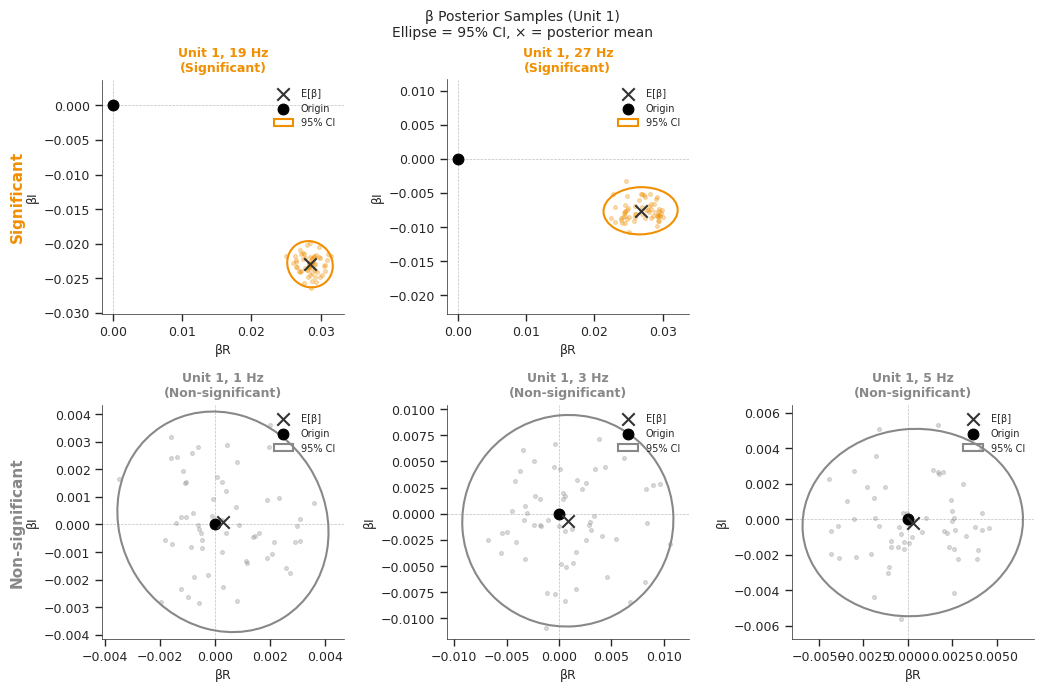

In [25]:
from joint_ssmt.plotting.beta_posterior import plot_beta_posterior_scatter

fig = plot_beta_posterior_scatter(
    coupling['beta_trace'],
    freqs,
    None,  # pass a file path to save, or None = display only
    unit_idx=1,
    burn_in_frac=0.6,
)
plt.show()


### 4b. Phase distribution


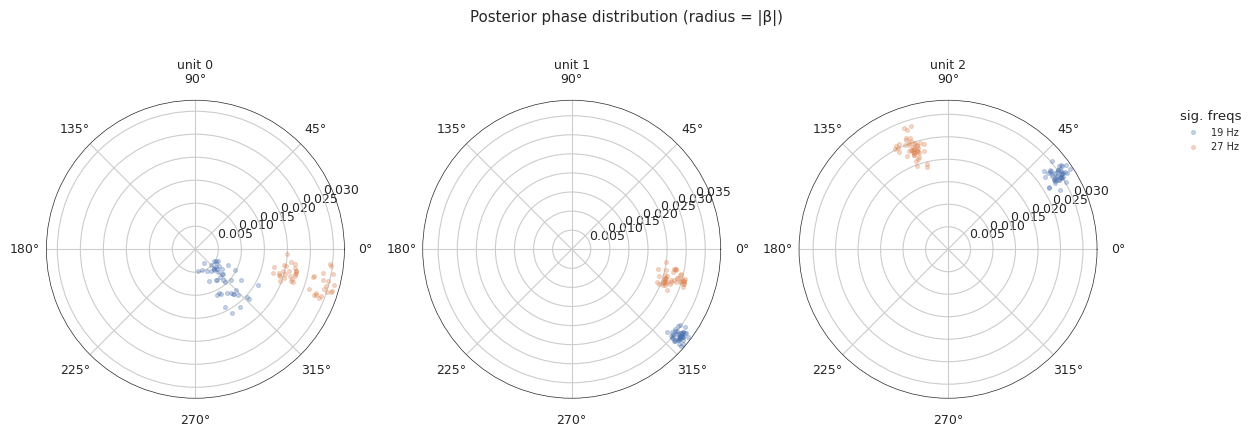

In [26]:
# Polar view of the posterior phase distribution at significant frequencies.
beta_trace = coupling['beta_trace']
J_grid = len(freqs)
burn = int(0.7 * beta_trace.shape[0])
bR = beta_trace[burn:, :, 1:1+J_grid]
bI = beta_trace[burn:, :, 1+J_grid:1+2*J_grid]
phase_samples = np.arctan2(bI, bR)
mag_samples = np.sqrt(bR**2 + bI**2)

rng = np.random.default_rng(0)
n_show = min(400, phase_samples.shape[0])
idx = rng.choice(phase_samples.shape[0], n_show, replace=False)

fig, axes = plt.subplots(1, S, figsize=(4.2 * S, 4.2),
                         subplot_kw={'projection': 'polar'})
if S == 1:
    axes = [axes]

for s in range(S):
    ax = axes[s]
    sig = wald_pval[s] < 0.05
    for j in np.where(sig)[0]:
        ax.scatter(phase_samples[idx, s, j], mag_samples[idx, s, j],
                   alpha=0.3, s=8, label=f'{freqs[j]:.0f} Hz')
    ax.set_title(f'unit {s}', y=1.08)
    if s == S - 1 and sig.any():
        ax.legend(bbox_to_anchor=(1.25, 1), fontsize=7, loc='upper left',
                  title='sig. freqs')

plt.suptitle('Posterior phase distribution (radius = |β|)', y=1.02)
plt.tight_layout()
plt.show()


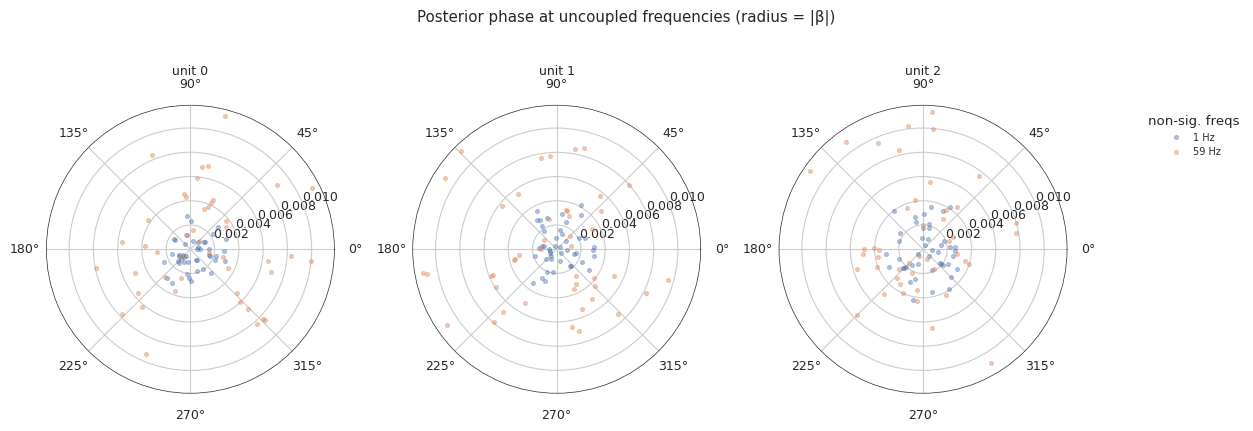

In [27]:
# Polar view at NON-significant (uncoupled) frequencies, for contrast.
n_uncoupled_show = 2

fig, axes = plt.subplots(1, S, figsize=(4.2 * S, 4.2),
                         subplot_kw={'projection': 'polar'})
if S == 1:
    axes = [axes]

for s in range(S):
    ax = axes[s]
    nonsig_idx = np.where(wald_pval[s] >= 0.05)[0]
    if len(nonsig_idx) > n_uncoupled_show:
        pick = np.linspace(0, len(nonsig_idx) - 1, n_uncoupled_show, dtype=int)
        chosen = nonsig_idx[pick]
    else:
        chosen = nonsig_idx
    for j in chosen:
        ax.scatter(phase_samples[idx, s, j], mag_samples[idx, s, j],
                   alpha=0.4, s=8, label=f'{freqs[j]:.0f} Hz')
    ax.set_title(f'unit {s}', y=1.08)
    if s == S - 1 and len(chosen) > 0:
        ax.legend(bbox_to_anchor=(1.25, 1), fontsize=7, loc='upper left',
                  title='non-sig. freqs')

plt.suptitle('Posterior phase at uncoupled frequencies (radius = |β|)', y=1.02)
plt.tight_layout()
plt.show()
